In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from useful_functions import *

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
color_data      = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_with_Flux.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')
SPECTRA = Spectrum(spectra_data, color_data, cigale_data, fastspecfit)

# spectra_data    = fits.open('/pscratch/sd/h/hyp0515/DESI-ML-EJ/extract_spectrum_desi/spring_half_BGS_1112.fits')
# color_data      = fits.open('/pscratch/sd/h/hyp0515/DESI-ML-EJ/extract_spectrum_desi/0715_Spring_half_BGS_BRIGHT_catalog_with_Flux.fits')

sfg_crit = SPECTRA.SFG_criteria(exclude=False)
qso_crit    = SPECTRA.subtype_criteria(subtype='QSO', exclude=True)

SPECTRA.subset(criteria=sfg_crit & qso_crit)
# SPECTRA.shrink_dataset(20)
SPECTRA.stack_data()
SPECTRA.mask_bad()

In [3]:
FIT     = FitSpectrum()
SPECTRA = FIT.shift_to_rest_frame(SPECTRA)
print(SPECTRA.n_spectra)


59793


In [4]:

SPECTRA = FIT.significant_emission_filter(SPECTRA)
print(SPECTRA.n_spectra)

48225


In [520]:
idx = np.random.choice(SPECTRA.n_spectra, size=1, replace=False)[0]
id = SPECTRA.targetID[idx]
# id = 39627806144991462
# idx = SPECTRA.id2index(id)

39627751845528019
Saved ./images/39627751845528019_image.jpg


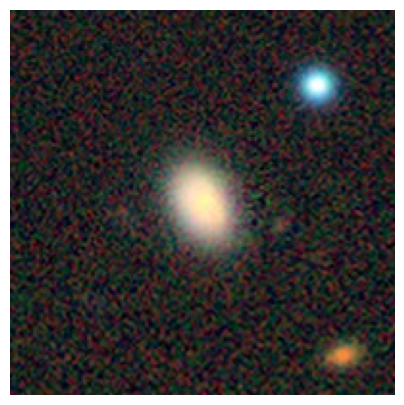

https://www.legacysurvey.org/viewer?ra=200.02483481521378&dec=-1.4250005338997207&layer=ls-dr10-grz&zoom=14
https://www.legacysurvey.org/viewer/desi-spectrum/dr1/targetid39627751845528019


In [521]:
print(SPECTRA.targetID[idx])
print(image_link(SPECTRA.RA[idx], SPECTRA.DEC[idx], plot=True, save_image=True, fname=f"./images/{SPECTRA.targetID[idx]}_image.jpg"))
print(spectrum_link(SPECTRA.targetID[idx]))

In [522]:
# params = FIT.fit_z(SPECTRA, id=id)

# if isinstance(params, str):
#     print(f'Fitting failed: {params}')
# else:

#     if not isinstance(params['sigma'], tuple): # one comp
#         print('1 comp.')
#         print(f'dz: {params["dz"]}')
#     else:
#         if params['dz_centroid'] is None:
#             print('2 comp with dz.')
#             print(f'dz: {params["dz"]}')
#         else:
#             print('2 comp free.')
#             print(f'dz_centroid: {params["dz_centroid"]}')
        
    

# 1-Comp fit with dz

In [523]:
params_1comp_fixed, (combine_lam, combine_flux, combine_sigma), seperation = FIT.fit_onhs_dz_modified(SPECTRA, id=id, two_component=False, w_dz=True)
OII_sep, OIII_sep = seperation
print(f'dz: {params_1comp_fixed["dz"]}')

combine_flux_1comp_fixed = combine_flux


gaussian_comp = np.concatenate([model(combine_lam[:OII_sep], gaussian_parms=params_1comp_fixed['gaussian_params']), 
                                model(combine_lam[OII_sep:OIII_sep+OII_sep], gaussian_parms=params_1comp_fixed['gaussian_params']),
                                model(combine_lam[OIII_sep+OII_sep:], gaussian_parms=params_1comp_fixed['gaussian_params'])])
model_1comp_fixed = gaussian_comp

chisq_1comp_fixed = np.sum(((combine_flux_1comp_fixed - model_1comp_fixed)/combine_sigma)**2)
# print(f'Chi-sq dz 1 comp: {chisq_dz_1comp}')


dof_1comp_fixed = len(combine_lam) - (2+8)
# 2: dz, sigma_1
# 8: amp_OII, amp_Hbeta, amp_OIII, amp_Halpha, amp_NII*2, amp_SII*2

dz: -3.245850442739328e-05


# 1-Comp without dz

In [524]:
params_1comp_free, (combine_lam, combine_flux, combine_sigma), seperation = FIT.fit_onhs_dz_modified(SPECTRA, id=id, two_component=False, w_dz=False)
OII_sep, OIII_sep = seperation

combine_flux_1comp_free = combine_flux


gaussian_comp = np.concatenate([model(combine_lam[:OII_sep], gaussian_parms=params_1comp_free['gaussian_params']), 
                                model(combine_lam[OII_sep:OIII_sep+OII_sep], gaussian_parms=params_1comp_free['gaussian_params']),
                                model(combine_lam[OIII_sep+OII_sep:], gaussian_parms=params_1comp_free['gaussian_params'])])
model_1comp_free = gaussian_comp

chisq_1comp_free = np.sum(((combine_flux_1comp_free - model_1comp_free)/combine_sigma)**2)
# print(f'Chi-sq dz 1 comp: {chisq_dz_1comp}')


dof_1comp_free = len(combine_lam) - (1+8)
# 1: sigma_1
# 8: amp_OII, amp_Hbeta, amp_OIII, amp_Halpha, amp_NII*2, amp_SII*2

# 2-Comp fit with dz, dz1, dz2

In [525]:

params_2comp_fixed, (combine_lam, combine_flux, combine_sigma), seperation = FIT.fit_onhs_dz_modified(SPECTRA, id=id, two_component=True, w_dz=True)
OII_sep, OIII_sep = seperation
print(f'dz: {params_2comp_fixed["dz"]}')
print(f'dz1: {params_2comp_fixed["dlam"][0]}, dz2: {params_2comp_fixed["dlam"][1]}')
print(f'dz ratio (left/right): {np.abs(params_2comp_fixed["dlam"][1]/params_2comp_fixed["dlam"][0])}')

combine_flux_2comp_fixed = combine_flux

left_comp_dz_fixed = np.concatenate([model(combine_lam[:OII_sep], gaussian_parms=params_2comp_fixed['left_comp'][:2]), 
                                     model(combine_lam[OII_sep:OIII_sep+OII_sep], gaussian_parms=params_2comp_fixed['left_comp'][2:2+3]),
                                     model(combine_lam[OIII_sep+OII_sep:], gaussian_parms=params_2comp_fixed['left_comp'][5:])])
right_comp_dz_fixed = np.concatenate([model(combine_lam[:OII_sep], gaussian_parms=params_2comp_fixed['right_comp'][:2]), 
                                      model(combine_lam[OII_sep:OIII_sep+OII_sep], gaussian_parms=params_2comp_fixed['right_comp'][2:2+3]),
                                      model(combine_lam[OIII_sep+OII_sep:], gaussian_parms=params_2comp_fixed['right_comp'][5:])])
model_2comp_fixed = left_comp_dz_fixed + right_comp_dz_fixed

chisq_2comp_fixed = np.sum(((combine_flux_2comp_fixed - model_2comp_fixed)/combine_sigma)**2)
# print(f'Chi-sq dz fixed: {chisq_dz_fixed}')


dof_2comp_fixed = len(combine_lam) - (5+8*2)
# 5: dz, sigma_1, sigma_2, dz_r, dz_l
# 8*2: (amp_OII, amp_Hbeta, amp_OIII, amp_Halpha, amp_NII*2, amp_SII*2)*2 two components

dz: 7.249309265172208e-05
dz1: 0.0003245993356408513, dz2: -0.00031740676185171675
dz ratio (left/right): 0.9778416866598499


# 2-Comp fit with dz1, dz2

In [526]:
params_2comp_free, (combine_lam, combine_flux, combine_sigma), seperation = FIT.fit_onhs_dz_modified(SPECTRA, id=id, two_component=True, w_dz=False)
print(f'dz: {params_2comp_free["dz"]}')

combine_flux_2comp_free = combine_flux

left_comp_dz_free = np.concatenate([model(combine_lam[:OII_sep], gaussian_parms=params_2comp_free['left_comp'][:2]), 
                                     model(combine_lam[OII_sep:OIII_sep+OII_sep], gaussian_parms=params_2comp_free['left_comp'][2:2+3]),
                                     model(combine_lam[OIII_sep+OII_sep:], gaussian_parms=params_2comp_free['left_comp'][5:])])
right_comp_dz_free = np.concatenate([model(combine_lam[:OII_sep], gaussian_parms=params_2comp_free['right_comp'][:2]), 
                                      model(combine_lam[OII_sep:OIII_sep+OII_sep], gaussian_parms=params_2comp_free['right_comp'][2:2+3]),
                                      model(combine_lam[OIII_sep+OII_sep:], gaussian_parms=params_2comp_free['right_comp'][5:])])
model_2comp_free = left_comp_dz_free + right_comp_dz_free

chisq_2comp_free = np.sum(((combine_flux_2comp_free - model_2comp_free)/combine_sigma)**2)
# print(f'Chi-sq dz free: {chisq_dz_free}')


left_area = np.sum(left_comp_dz_free)
right_area = np.sum(right_comp_dz_free)
dz1, dz2 = params_2comp_free['dz']
dz_centroid = (dz2*left_area + dz1*right_area)/(left_area+right_area)
print(f'dz_centroid: {dz_centroid}')

dof_2comp_free = len(combine_lam) - (4+8*2)
# 4: sigma_1, sigma_2, dz_r, dz_l
# 8*2: (amp_OII, amp_Hbeta, amp_OIII, amp_Halpha, amp_NII*2, amp_SII*2)*2 two components


dz: (np.float64(0.00039709808446043943), np.float64(-0.00024490939020074717))
dz_centroid: -2.9321782392816253e-06


In [527]:
F_stat = ((chisq_1comp_fixed - chisq_2comp_fixed) / (dof_1comp_fixed - dof_2comp_fixed)) / (chisq_2comp_fixed / dof_2comp_fixed)
p_value = 1 - f.cdf(F_stat, dof_1comp_fixed - dof_2comp_fixed, dof_2comp_fixed)
print(f'Fixed p_value: {p_value}')


F_stat = ((chisq_1comp_free - chisq_2comp_free) / (dof_1comp_free - dof_2comp_free)) / (chisq_2comp_free / dof_2comp_free)
p_value = 1 - f.cdf(F_stat, dof_1comp_free - dof_2comp_free, dof_2comp_free)
print(f'Free p_value: {p_value}')



# F_stat = ((chisq_2comp_free - chisq_2comp_fixed) / (dof_1comp_free - dof_2comp_fixed)) / (chisq_2comp_fixed / dof_2comp_fixed)
# p_value = 1 - f.cdf(F_stat, dof_1comp_free - dof_2comp_fixed, dof_2comp_fixed)
# print(f'2comp vs p_value (if < 0.05, w/ dz): {p_value}')

Fixed p_value: 1.1102230246251565e-16
Free p_value: 1.1102230246251565e-16


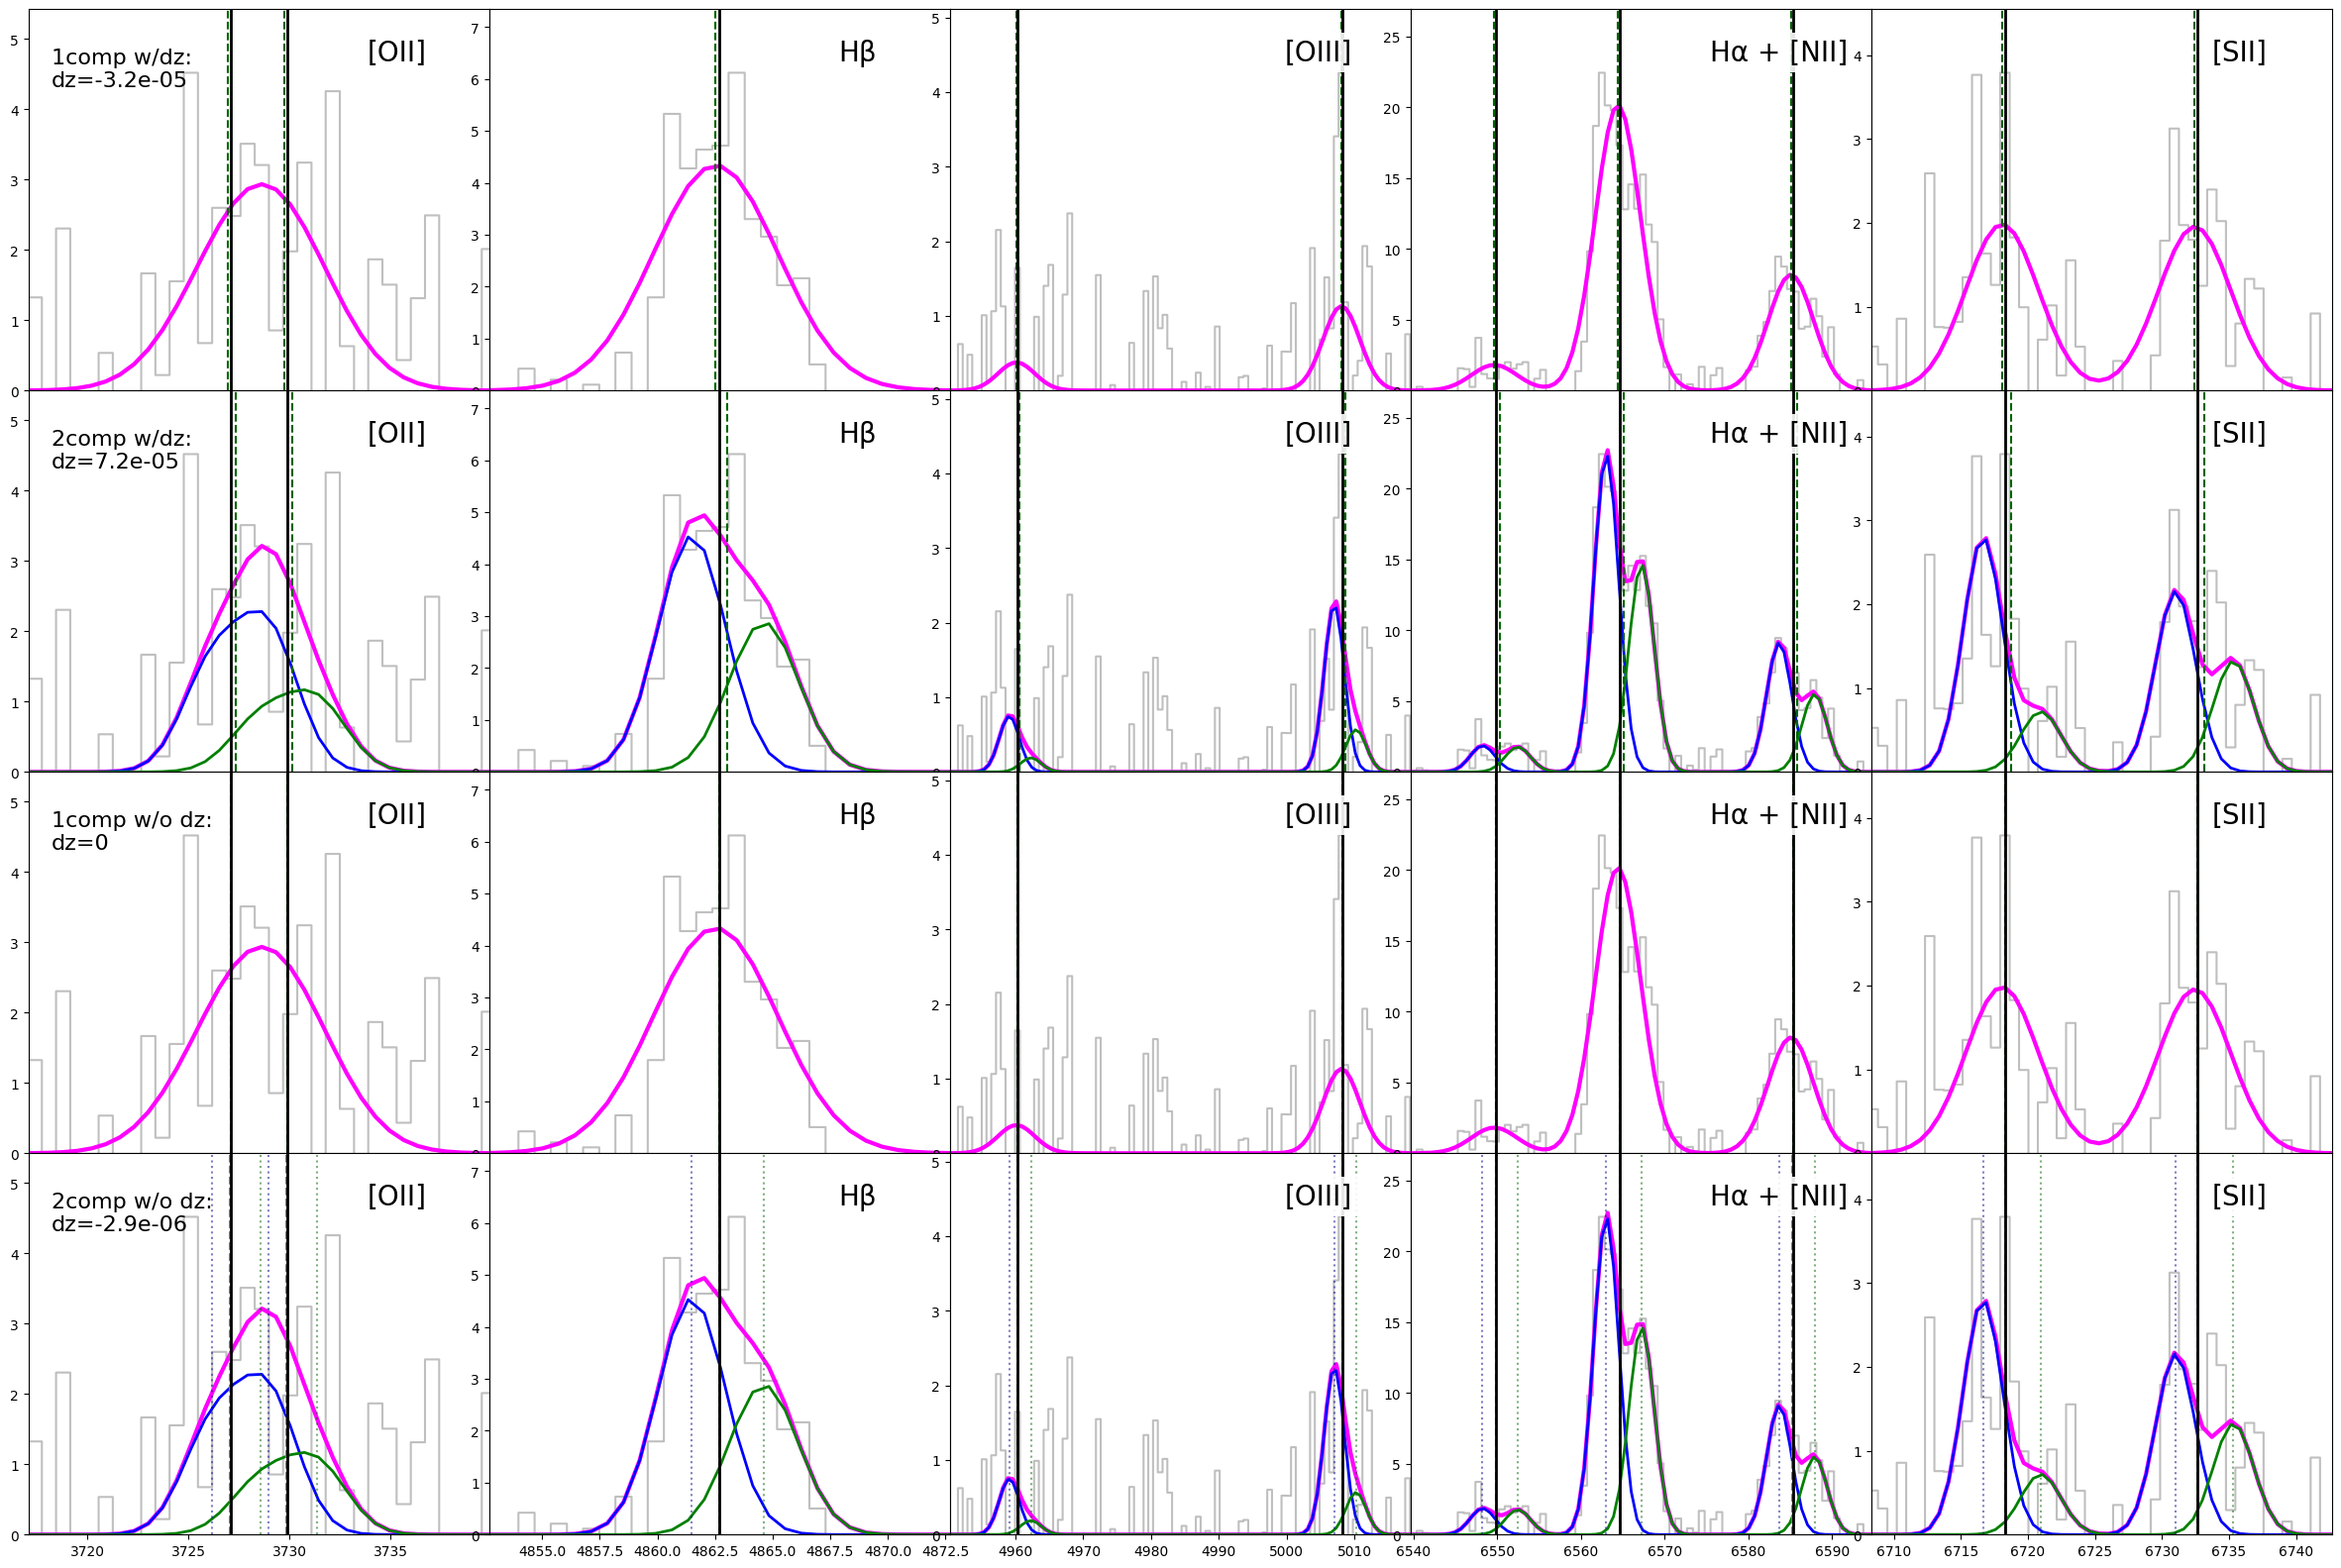

In [528]:

fig, axes = plt.subplots(4, 5, figsize=(30, 20))
plt.subplots_adjust(hspace=0.0, wspace=0.00)


# 1 comp fixed
ax = axes[0, :]
ax[0].text(0.05, 0.9, f'1comp w/dz: \ndz={params_1comp_fixed["dz"]:.1e}', transform=ax[0].transAxes, fontsize=16, verticalalignment='top')
for i in range(5):
    ax[i].step(combine_lam, combine_flux_1comp_fixed, label='Observed', where='mid', color='gray', alpha=0.5)
    ax[i].plot(combine_lam, model_1comp_fixed, label='Fitted Model', color='magenta', linewidth=3)
    for l0 in [*lines_vac['OII'], *lines_vac['OIII'], *lines_vac['Hbeta'], *lines_vac['Halpha'], *lines_vac['NII'], *lines_vac['SII']]:
        ax[i].axvline(l0*(1+params_1comp_fixed['dz']), color='darkgreen', linestyle='--', alpha=1, linewidth=1.5)
        ax[i].axvline(l0, color='k', linestyle='-', alpha=1, linewidth=2)

# 2 comp fixed
ax = axes[1, :]
ax[0].text(0.05, 0.9, f'2comp w/dz: \ndz={params_2comp_fixed["dz"]:.1e}', transform=ax[0].transAxes, fontsize=16, verticalalignment='top')
for i in range(5):
    ax[i].step(combine_lam, combine_flux_2comp_fixed, label='Observed', where='mid', color='gray', alpha=0.5)
    ax[i].plot(combine_lam, model_2comp_fixed, label='Fitted Model', color='magenta', linewidth=3)
    ax[i].plot(combine_lam, left_comp_dz_fixed, label='Left Component', color='blue', linestyle='-', linewidth=2)
    ax[i].plot(combine_lam, right_comp_dz_fixed, label='Right Component', color='green', linestyle='-', linewidth=2)
    for l0 in [*lines_vac['OII'], *lines_vac['OIII'], *lines_vac['Hbeta'], *lines_vac['Halpha'], *lines_vac['NII'], *lines_vac['SII']]:
        ax[i].axvline(l0*(1+params_2comp_fixed['dz']), color='darkgreen', linestyle='--', alpha=1, linewidth=1.5)
        ax[i].axvline(l0, color='k', linestyle='-', alpha=1, linewidth=2)


# 1 comp free
ax = axes[2, :]
ax[0].text(0.05, 0.9, f'1comp w/o dz: \ndz=0', transform=ax[0].transAxes, fontsize=16, verticalalignment='top')
for i in range(5):
    ax[i].step(combine_lam, combine_flux_1comp_fixed, label='Observed', where='mid', color='gray', alpha=0.5)
    ax[i].plot(combine_lam, model_1comp_fixed, label='Fitted Model', color='magenta', linewidth=3)
    for l0 in [*lines_vac['OII'], *lines_vac['OIII'], *lines_vac['Hbeta'], *lines_vac['Halpha'], *lines_vac['NII'], *lines_vac['SII']]:
        ax[i].axvline(l0, color='darkgreen', linestyle='--', alpha=1, linewidth=1.5)
        ax[i].axvline(l0, color='k', linestyle='-', alpha=1, linewidth=2)


# 2 comp free
ax = axes[3, :]
ax[0].text(0.05, 0.9, f'2comp w/o dz: \ndz={dz_centroid:.1e}', transform=ax[0].transAxes, fontsize=16, verticalalignment='top')
for i in range(5):
    ax[i].step(combine_lam, combine_flux_2comp_free, label='Observed', where='mid', color='gray', alpha=0.5)
    ax[i].plot(combine_lam, model_2comp_free, label='Fitted Model', color='magenta', linewidth=3)
    ax[i].plot(combine_lam, left_comp_dz_free, label='Left Component', color='blue', linestyle='-', linewidth=2)
    ax[i].plot(combine_lam, right_comp_dz_free, label='Right Component', color='green', linestyle='-', linewidth=2)
    for l0 in [*lines_vac['OII'], *lines_vac['OIII'], *lines_vac['Hbeta'], *lines_vac['Halpha'], *lines_vac['NII'], *lines_vac['SII']]:
        ax[i].axvline(l0*(1+params_2comp_free['dz'][0]), color='darkgreen', linestyle=':', alpha=.5, linewidth=1.5)
        ax[i].axvline(l0*(1+params_2comp_free['dz'][1]), color='darkblue', linestyle=':', alpha=.5, linewidth=1.5)
        ax[i].axvline(l0*(1+dz_centroid), color='gray', linestyle='--', alpha=1, linewidth=1.5)
        ax[i].axvline(l0, color='k', linestyle='-', alpha=1, linewidth=2)

for i in range(4):
    ax = axes[i, :]
    ax[0].text(0.80, 0.85, '[OII]', transform=ax[0].transAxes, fontsize=20, horizontalalignment='center', verticalalignment='bottom', bbox =dict(facecolor='white', alpha=0.9, edgecolor='none'))
    ax[0].set_xlim([OII_rest[0]-10, OII_rest[1]+10])  
    ax[0].set_ylim(bottom=-0., top=np.max(combine_flux_2comp_free[(combine_lam>=OII_rest[0]-10) & (combine_lam<=OII_rest[1]+10)])*1.2)

    ax[1].text(0.80, 0.85, 'Hβ', transform=ax[1].transAxes, fontsize=20, horizontalalignment='center', verticalalignment='bottom', bbox =dict(facecolor='white', alpha=0.9, edgecolor='none'))
    ax[1].set_xlim([Hbeta_rest[0]-10, Hbeta_rest[0]+10])
    ax[1].set_ylim(bottom=-0., top=np.max(combine_flux_2comp_free[(combine_lam>=Hbeta_rest[0]-10) & (combine_lam<=Hbeta_rest[0]+10)])*1.2)

    ax[2].text(0.80, 0.85, '[OIII]', transform=ax[2].transAxes, fontsize=20, horizontalalignment='center', verticalalignment='bottom', bbox =dict(facecolor='white', alpha=0.9, edgecolor='none'))
    ax[2].set_xlim([OIII_rest[0]-10, OIII_rest[1]+10])
    ax[2].set_ylim(bottom=-0., top=np.max(combine_flux_2comp_free[(combine_lam>=OIII_rest[0]-10) & (combine_lam<=OIII_rest[1]+10)])*1.2)

    ax[3].text(0.80, 0.85, 'Hα + [NII]', transform=ax[3].transAxes, fontsize=20, horizontalalignment='center', verticalalignment='bottom', bbox =dict(facecolor='white', alpha=0.9, edgecolor='none'))
    ax[3].set_xlim([Halpha_rest[0]-25, Halpha_rest[0]+30])
    ax[3].set_ylim(bottom=-0., top=np.max(combine_flux_2comp_free[(combine_lam>=Halpha_rest[0]-25) & (combine_lam<=Halpha_rest[0]+30)])*1.2)

    ax[4].text(0.80, 0.85, '[SII]', transform=ax[4].transAxes, fontsize=20, horizontalalignment='center', verticalalignment='bottom', bbox =dict(facecolor='white', alpha=0.9, edgecolor='none'))
    ax[4].set_xlim([SII_rest[0]-10, SII_rest[1]+10])
    ax[4].set_ylim(bottom=-0., top=np.max(combine_flux_2comp_free[(combine_lam>=SII_rest[0]-10) & (combine_lam<=SII_rest[1]+10)])*1.2)


# plt.savefig(f'./figures/Nov26/fit_comparison_{id}.png')
plt.show()

In [529]:
# import numpy as np
# from joblib import Parallel, delayed
# import os
# from tqdm import tqdm

# def fit_spectrum_worker(target_id):
#     """A wrapper function for the fitting process to be used by the executor."""
#     return FIT.fit_z(SPECTRA, id=target_id)

# n_jobs = 10

# results = Parallel(n_jobs=n_jobs)(delayed(fit_spectrum_worker)(i) for i in tqdm(SPECTRA.targetID))


In [530]:
# failed = []
# prefer_1comp = []
# prefer_2comp_wdz = []
# prefer_2comp_free = []

# for i, params in enumerate(results):
#     if isinstance(params, str):
#         failed.append(SPECTRA.targetID[i])
#     else:
#         if not isinstance(params['sigma'], tuple): # one comp
#             prefer_1comp.append(SPECTRA.targetID[i])
#         else:
#             if params['dz_centroid'] is None:
#                 prefer_2comp_wdz.append(SPECTRA.targetID[i])
#             else:
#                 prefer_2comp_free.append(SPECTRA.targetID[i])


In [531]:
# print(len(failed), len(prefer_1comp), len(prefer_2comp_wdz), len(prefer_2comp_free))

In [532]:
# from matplotlib.lines import Line2D

# for id in failed:
#     z_pipe = SPECTRA.z[SPECTRA.id2index(id)]
#     plt.scatter(z_pipe, 1e-10, color='gray', alpha=0.3)


# for id in prefer_1comp:
#     z_pipe = SPECTRA.z[SPECTRA.id2index(id)]
#     dz = results[SPECTRA.id2index(id)]['dz']
#     plt.scatter(z_pipe, dz, color='b', alpha=0.3)

# for id in prefer_2comp_wdz:
#     z_pipe = SPECTRA.z[SPECTRA.id2index(id)]
#     dz = results[SPECTRA.id2index(id)]['dz']
#     plt.scatter(z_pipe, dz, color='orange', alpha=0.3)

# for id in prefer_2comp_free:
#     z_pipe = SPECTRA.z[SPECTRA.id2index(id)]
#     dz_centroid = results[SPECTRA.id2index(id)]['dz_centroid']
#     plt.scatter(z_pipe, dz_centroid, color='r', alpha=0.3)


# plt.axhline(5e-5, color='k', linestyle='--', alpha=0.7)

# # Create custom legend handles
# legend_elements = [Line2D([0], [0], marker='o', color='w', label='Failed', markerfacecolor='k', markersize=10, alpha=0.3),
#                    Line2D([0], [0], marker='o', color='w', label='1 comp', markerfacecolor='b', markersize=10, alpha=0.3),
#                    Line2D([0], [0], marker='o', color='w', label='2 comp w/dz', markerfacecolor='orange', markersize=10, alpha=0.3),
#                    Line2D([0], [0], marker='o', color='w', label='2 comp free', markerfacecolor='r', markersize=10, alpha=0.3)]

# plt.legend(handles=legend_elements, loc='lower left')

# plt.yscale('log')
# plt.xlabel('z')
# plt.ylabel('dz')
# plt.savefig('./figures/Nov26/dz_vs_z.png')
# plt.show()

In [533]:
# tilted_cases = []
# for id in prefer_2comp_wdz:
#     dz_r, dz_l = results[SPECTRA.id2index(id)]['dlam']
#     dz_ratio = np.abs(dz_r/dz_l)
#     if (((dz_ratio > 2.0) and (dz_ratio < 20)) or ((dz_ratio>0.05) and (dz_ratio < 0.5))) and (max(dz_r, dz_l) > 1e-7):
#         tilted_cases.append((id, dz_ratio))

In [534]:
# print(tilted_cases)

In [535]:
# high_dz_cases = []
# for id in prefer_2comp_wdz:
#     dz = results[SPECTRA.id2index(id)]['dz']
#     if (np.abs(dz) > 1e-4):
#         high_dz_cases.append((id, dz))
        



In [536]:
# sorted_high_dz = sorted(high_dz_cases, key=lambda x: np.abs(x[1]), reverse=True)
# # first 10 high dz cases
# print(sorted_high_dz[:10])